# Tabular Machine Learning Models for Walmart Sales Forecasting

This notebook trains, evaluates, and compares nine different machine learning models and neural networks on the Walmart sales forecasting task. We use the tabular features engineered in previous steps and evaluate all models using the standard validation split to ensure direct comparison with our baseline and statistical models.

To prevent OpenMP / C-runtime DLL clashes and access violations on Windows (which typically occur when Intel MKL/OpenMP are preloaded in the Jupyter kernel by other modules), the actual model training is orchestrated in a clean, isolated standalone subprocess via `src/train_ml_models.py`. The notebook then loads the generated predictions and metrics to run deep visual diagnostics and residual diagnostics.

## Models Implemented:
1. **Linear Regression** (OLS)
2. **Random Forest Regressor** (Bagging ensemble of decision trees)
3. **K-Nearest Neighbors (KNN)**
4. **XGBoost Regressor** (Gradient boosted trees with regularization)
5. **LightGBM Regressor** (Leaf-wise histogram gradient boosted trees)
6. **Multi-Layer Perceptron (MLP)** (Scikit-Learn Multi-Layer Perceptron)
7. **Artificial Neural Network (ANN)** (PyTorch feed-forward network with linear & ReLU layers)
8. **Gradient Boosted Regression Trees (GBRT)** (Scikit-Learn Gradient Boosting Regressor)
9. **Ensemble Regressor** (Simple average of Random Forest + XGBoost + LightGBM + MLP predictions)

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import lightgbm
import sys
import time
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# Append project root
sys.path.append(os.path.abspath(".."))

from src import config
from src.evaluate_models import (
    evaluate_predictions,
    calculate_wmae,
    calculate_mae
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

np.random.seed(42)

## 1. Load and Validate Data

We load the engineered features from `data/processed/train_features.csv` to validate the columns and types.

In [2]:
# Load engineered features robustly depending on CWD
if Path("data").exists():
    features_path = Path("data/processed/train_features.csv")
else:
    features_path = Path("../data/processed/train_features.csv")
df = pd.read_csv(features_path)

# Standardize IsHoliday to boolean
if df["IsHoliday"].dtype == "object":
    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
    )
df["IsHoliday"] = df["IsHoliday"].astype(bool)
df["Date"] = pd.to_datetime(df["Date"])

# Define features list
feature_cols = [
    'Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear', 'Quarter',
    'Is_Q4', 'Is_Holiday_Month', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
    'MarkDown_Total', 'Has_MarkDown', 'MarkDown_Avg', 'MarkDown_Max',
    'Weekly_Sales_lag_1', 'Weekly_Sales_lag_2', 'Weekly_Sales_lag_3', 'Weekly_Sales_lag_4',
    'Weekly_Sales_lag_8', 'Weekly_Sales_lag_12', 'Weekly_Sales_lag_26', 'Weekly_Sales_lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_mean_26', 'rolling_mean_52',
    'rolling_std_4', 'rolling_std_12', 'rolling_std_52',
    'Store_Avg_Sales', 'Dept_Avg_Sales', 'Store_Dept_Avg_Sales',
    'Type_Encoded', 'Holiday_MarkDown', 'Q4_Holiday', 'Size_MarkDown'
]

print(f"Tabular features count: {len(feature_cols)}")
print(f"Total raw rows: {len(df):,}")

Tabular features count: 44
Total raw rows: 421,570


## 2. Model Selection and Evaluation Setup

We set up the evaluation split date `2012-08-10` and verify the shape of the validation set.

In [3]:
# Identify train/val split boundaries
df_clean = df.dropna(subset=['Weekly_Sales'] + feature_cols).copy()
train_df = df_clean[df_clean["Date"] <= "2012-08-10"].copy()
val_df_raw = df_clean[df_clean["Date"] > "2012-08-10"].copy()

print(f"Training rows:   {len(train_df):,}")
print(f"Validation rows: {len(val_df_raw):,}")

Training rows:   388,964
Validation rows: 32,606


## 4. Run Forecasting Models

We invoke the model training pipeline script in a clean process or load the pre-calculated results.

In [4]:
# Robust path resolution depending on CWD
if Path("results").exists():
    pred_path = Path("results/ml_predictions.csv")
    metrics_path = Path("results/ml_metrics.json")
    script_path = Path("src/train_ml_models.py")
else:
    pred_path = Path("../results/ml_predictions.csv")
    metrics_path = Path("../results/ml_metrics.json")
    script_path = Path("../src/train_ml_models.py")

if not pred_path.exists() or not metrics_path.exists():
    print("Pre-calculated results not found. Running training script in standalone process...")
    result = subprocess.run([sys.executable, str(script_path.resolve())], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(f"Error executing training pipeline: {result.stderr}")
else:
    print("Loading pre-calculated machine learning predictions and metrics...")

val_df = pd.read_csv(pred_path)
val_df["Date"] = pd.to_datetime(val_df["Date"])
y_val = val_df["Weekly_Sales"]

with open(metrics_path, "r") as f:
    metrics_dict = json.load(f)

# Build model metrics DataFrame
metrics_list = []
for model_name, info in metrics_dict.items():
    info["Model"] = model_name
    metrics_list.append(info)
metrics_df = pd.DataFrame(metrics_list)

print("Loaded metrics successfully!")

Loading pre-calculated machine learning predictions and metrics...


Loaded metrics successfully!


## 5. Prediction Coverage and Consistency Checks

We assert that there are no missing predictions across the forecast outputs.

In [5]:
model_names = list(metrics_dict.keys())
prediction_cols = [f"{name}_Pred" for name in model_names]

print("--- Prediction coverage check ---")
for col in prediction_cols:
    missing = val_df[col].isna().sum()
    print(f"{col} missing predictions: {missing:,}")
    assert missing == 0

--- Prediction coverage check ---
Random Forest_Pred missing predictions: 0
LightGBM_Pred missing predictions: 0
XGBoost_Pred missing predictions: 0
Ensemble_Pred missing predictions: 0
GBRT_Pred missing predictions: 0
KNN_Pred missing predictions: 0
Linear Regression_Pred missing predictions: 0
ANN_Pred missing predictions: 0
MLP_Pred missing predictions: 0


## 6. Model Error Comparison

We display the error metrics across all models, sorted by WMAE performance.

In [6]:
metrics_df_display = metrics_df[["Model", "WMAE", "MAE", "RMSE", "MAPE", "sMAPE", "Runtime (s)"]]
display(metrics_df_display)

,Model,WMAE,MAE,RMSE,MAPE,sMAPE,Runtime (s)
0,Random Forest,1292.527983,1230.298004,2560.279476,820.292790,17.593022,115.589140
1,LightGBM,1304.361540,1227.301402,2672.447653,161.494876,17.641427,17.806662
2,XGBoost,1357.429436,1275.747741,2821.774186,1037.703453,21.910059,2.949460
3,Ensemble,1419.136054,1298.523990,2629.265226,870.208600,27.026892,152.142864
4,GBRT,1457.421110,1359.671031,2753.774638,797.209170,24.430689,540.233141
5,KNN,1782.225644,1731.910120,3200.613029,5473.674913,31.084457,13.590409
6,Linear Regression,1830.556320,1743.575681,3465.224535,2635.254207,41.969191,1.682314
7,ANN,2460.018717,2406.544050,3622.349753,8225.518402,45.769766,61.054686
8,MLP,2592.141227,2132.640731,3521.176852,2834.806680,45.602906,30.601456


## 7. Visualizing Error Metrics

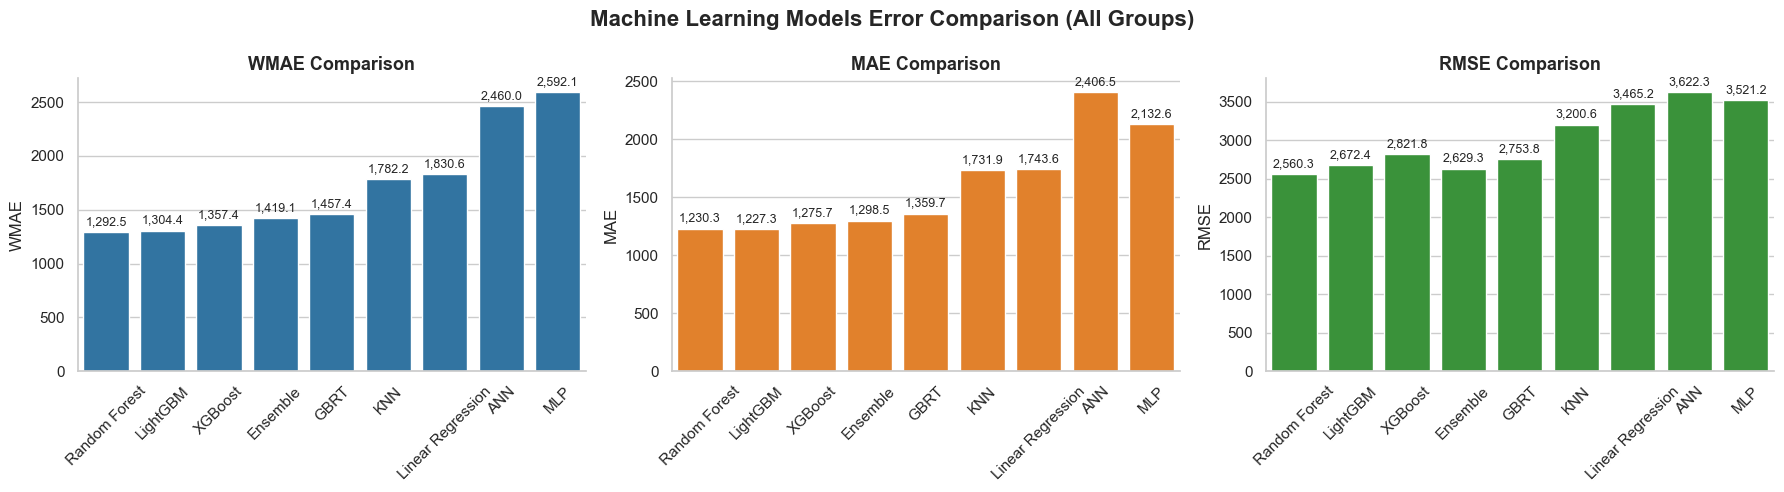

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_plot = ["WMAE", "MAE", "RMSE"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, metric in enumerate(metrics_plot):
    sns.barplot(data=metrics_df, x="Model", y=metric, ax=axes[idx], color=colors[idx])
    axes[idx].set_title(f"{metric} Comparison", fontsize=13, fontweight="bold")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel("")
    for p in axes[idx].patches:
        height = p.get_height()
        axes[idx].annotate(f'{height:,.1f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.suptitle("Machine Learning Models Error Comparison (All Groups)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Aggregate Weekly Forecast

We plot predicted vs actual sales across all validation dates to visualize alignment.

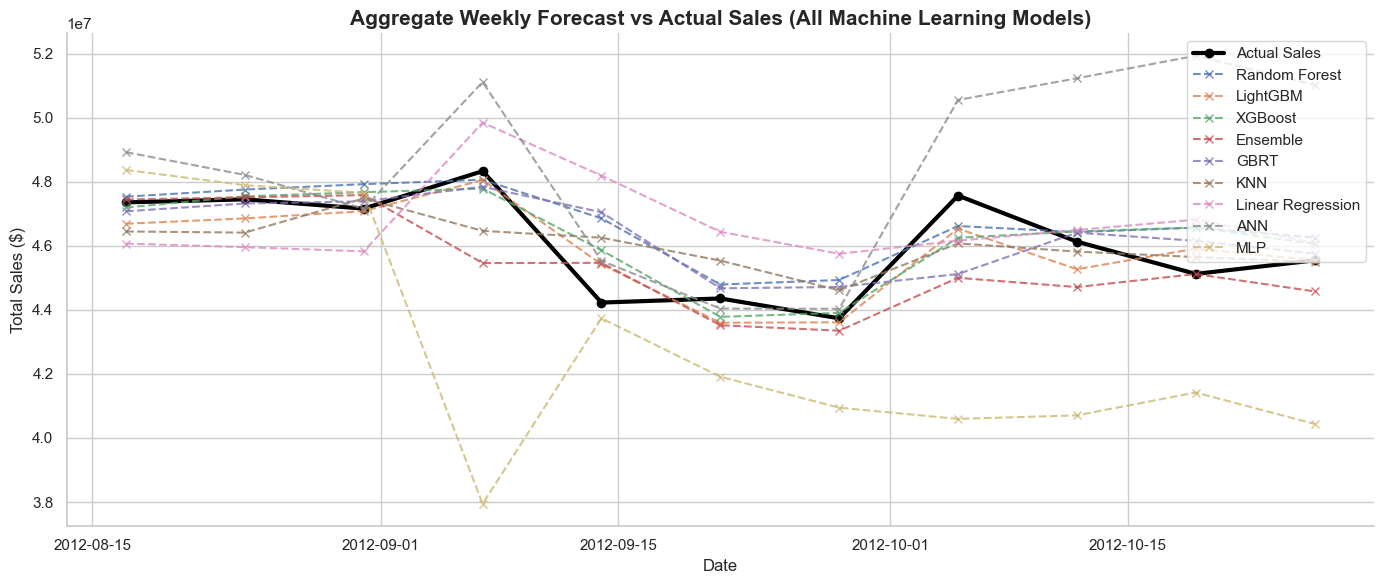

In [8]:
agg_sales = val_df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(agg_sales["Date"], agg_sales["Weekly_Sales"], label="Actual Sales", color="black", linewidth=3.0, marker="o")

for name in model_names:
    col_name = f"{name}_Pred"
    pred_agg = val_df.groupby("Date")[col_name].sum().reset_index()
    plt.plot(pred_agg["Date"], pred_agg[col_name], label=name, linestyle="--", marker="x", alpha=0.8)

plt.title("Aggregate Weekly Forecast vs Actual Sales (All Machine Learning Models)", fontsize=15, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

## 9. Actual vs Predicted Analysis

We construct scatter plots of predicted vs actual sales capped at the 99th percentile of sales values.

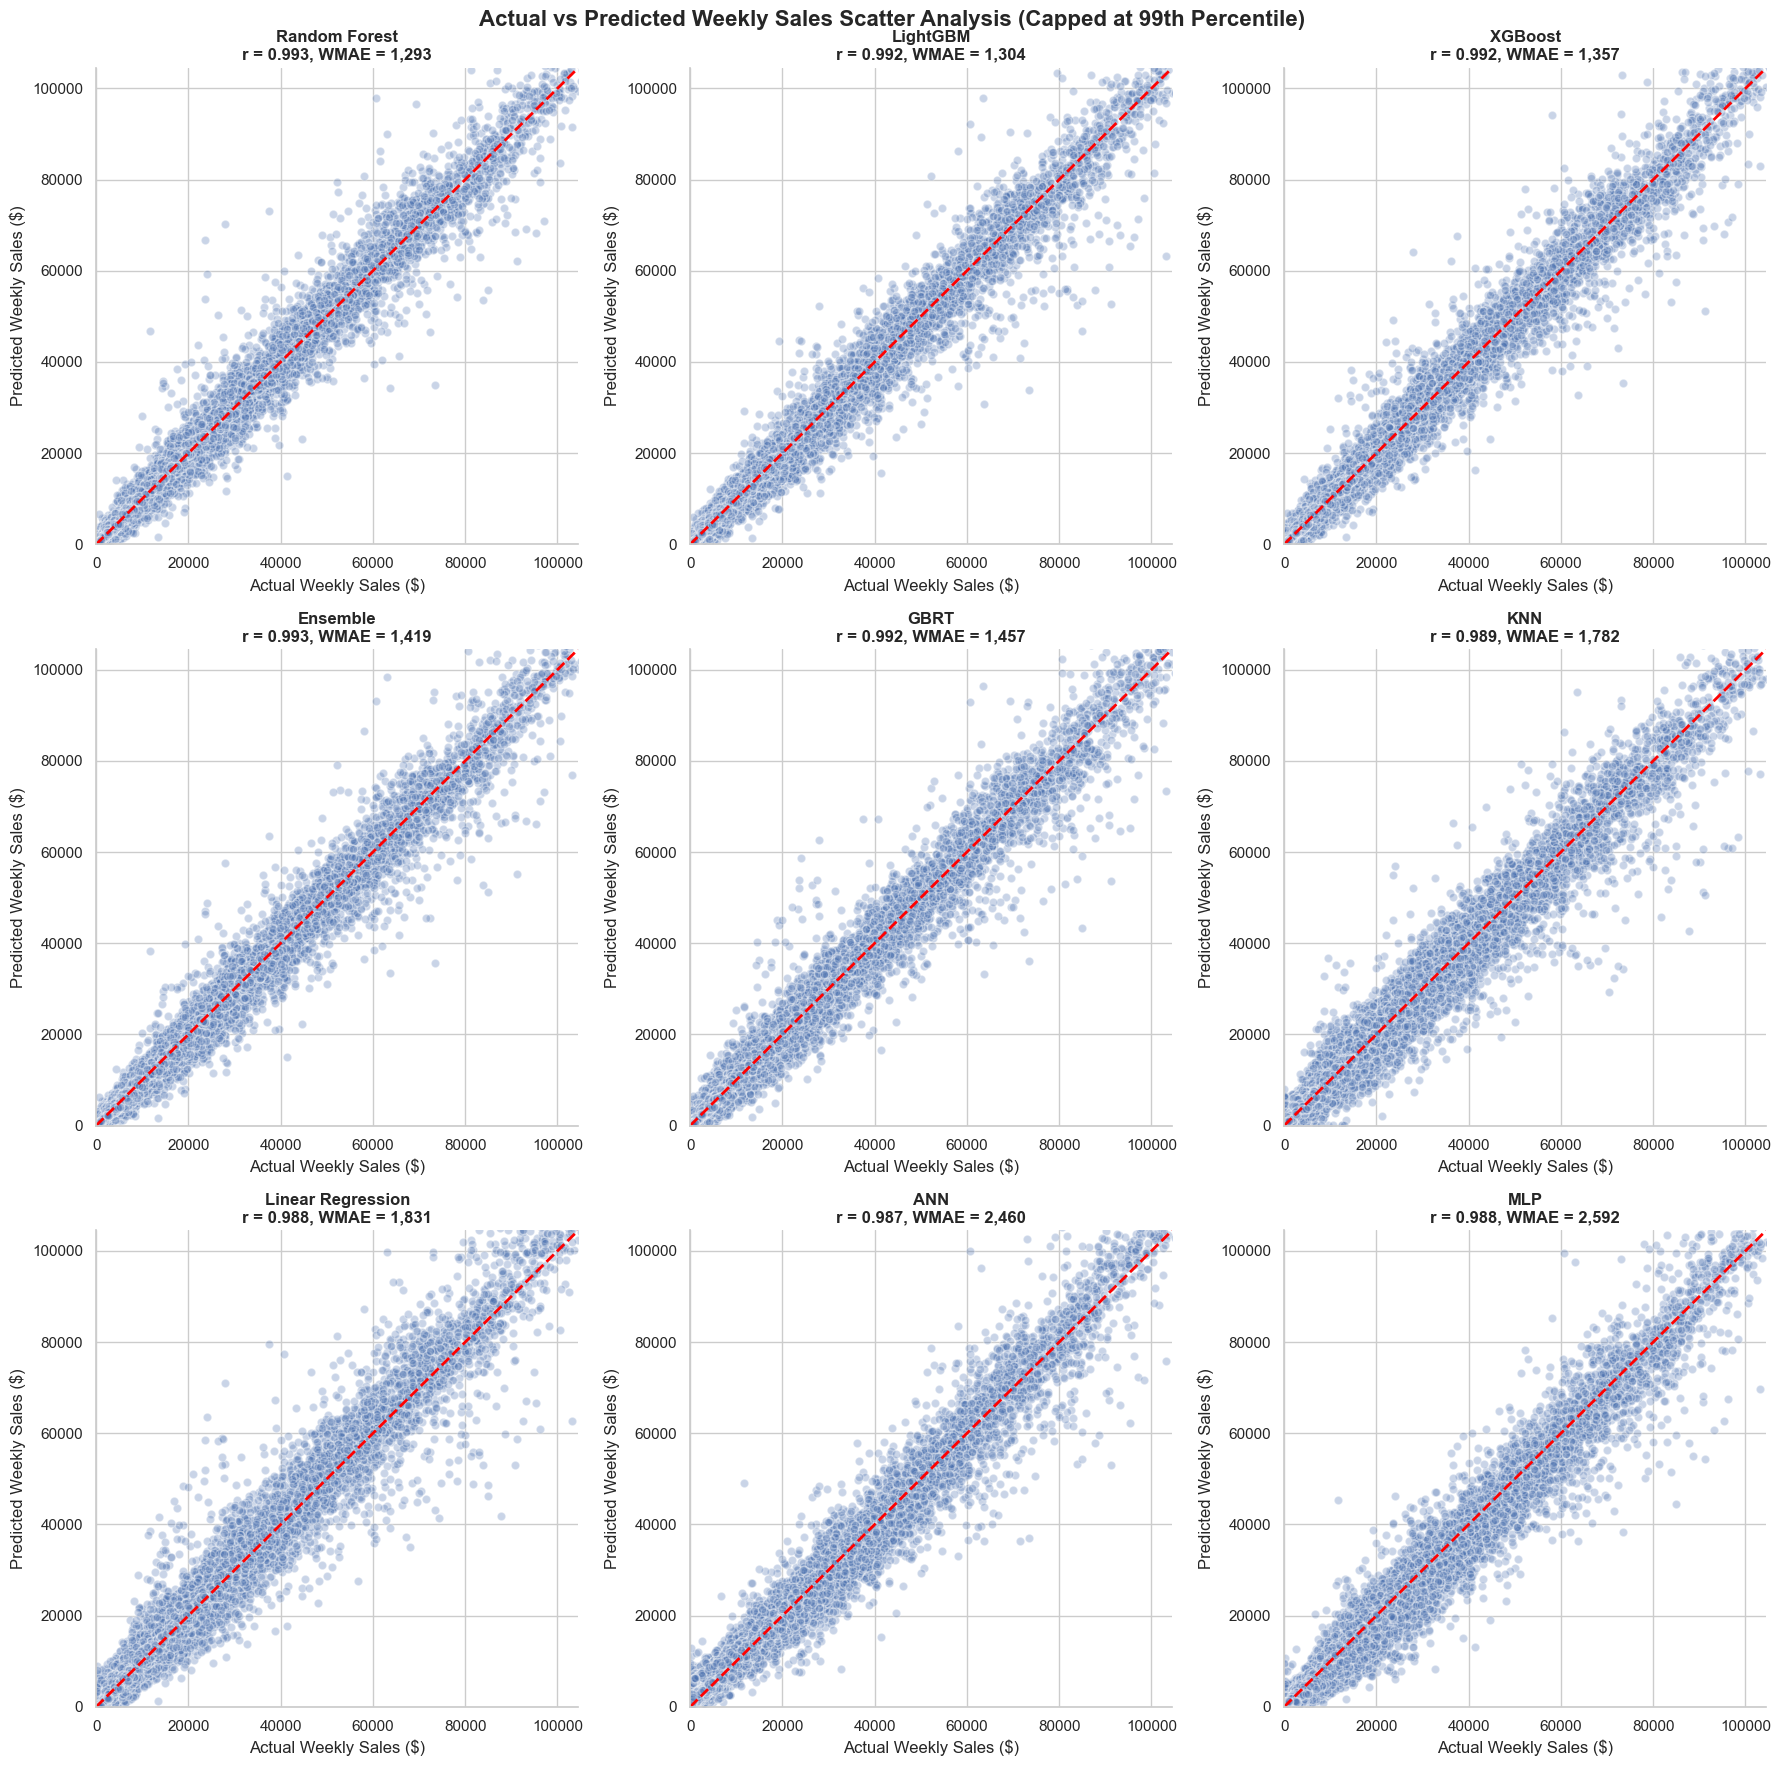

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

plot_limit = max(
    val_df["Weekly_Sales"].quantile(0.99),
    val_df[prediction_cols].quantile(0.99).max()
)

for idx, name in enumerate(model_names):
    col_name = f"{name}_Pred"
    ax = axes[idx]
    
    ax.scatter(val_df["Weekly_Sales"], val_df[col_name], alpha=0.3, color="#4c72b0", edgecolors="w")
    ax.plot([0, plot_limit], [0, plot_limit], color="red", linestyle="--", linewidth=2)
    ax.set_xlim(0, plot_limit)
    ax.set_ylim(0, plot_limit)
    
    corr = val_df["Weekly_Sales"].corr(val_df[col_name])
    model_wmae = metrics_df.set_index("Model").loc[name, "WMAE"]
    
    ax.set_title(f"{name}\nr = {corr:.3f}, WMAE = {model_wmae:,.0f}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Weekly Sales ($)")
    ax.set_ylabel("Predicted Weekly Sales ($)")
    
plt.suptitle("Actual vs Predicted Weekly Sales Scatter Analysis (Capped at 99th Percentile)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Holiday vs Non-Holiday Error Analysis

We compare MAE between Holiday and Non-Holiday subsets to check seasonal alignment.

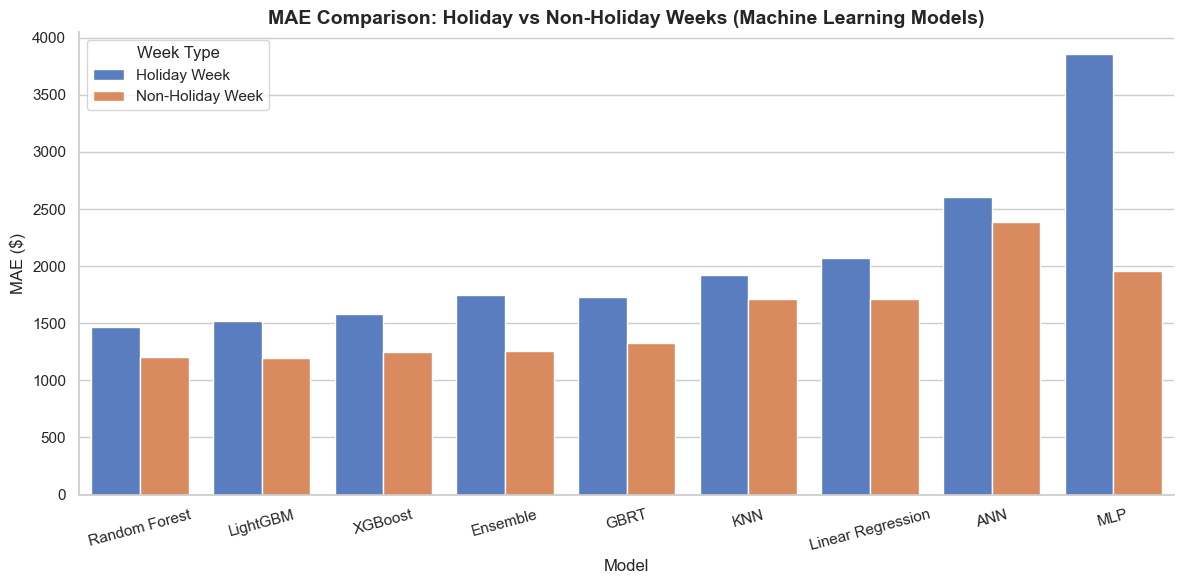

In [10]:
holiday_metrics = []

for is_hld in [True, False]:
    subset = val_df[val_df["IsHoliday"] == is_hld]
    for name in model_names:
        col_name = f"{name}_Pred"
        mae_val = calculate_mae(subset["Weekly_Sales"], subset[col_name])
        holiday_metrics.append({
            "Model": name,
            "Week Type": "Holiday Week" if is_hld else "Non-Holiday Week",
            "MAE": mae_val
        })

hld_df = pd.DataFrame(holiday_metrics)

plt.figure(figsize=(12, 6))
sns.barplot(data=hld_df, x="Model", y="MAE", hue="Week Type", palette="muted")
plt.title('MAE Comparison: Holiday vs Non-Holiday Weeks (Machine Learning Models)', fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("MAE ($)", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Week Type")
plt.tight_layout()
plt.show()

## 11. Residual Analysis

We check residuals (Actuals - Predictions) of the top-performing model.

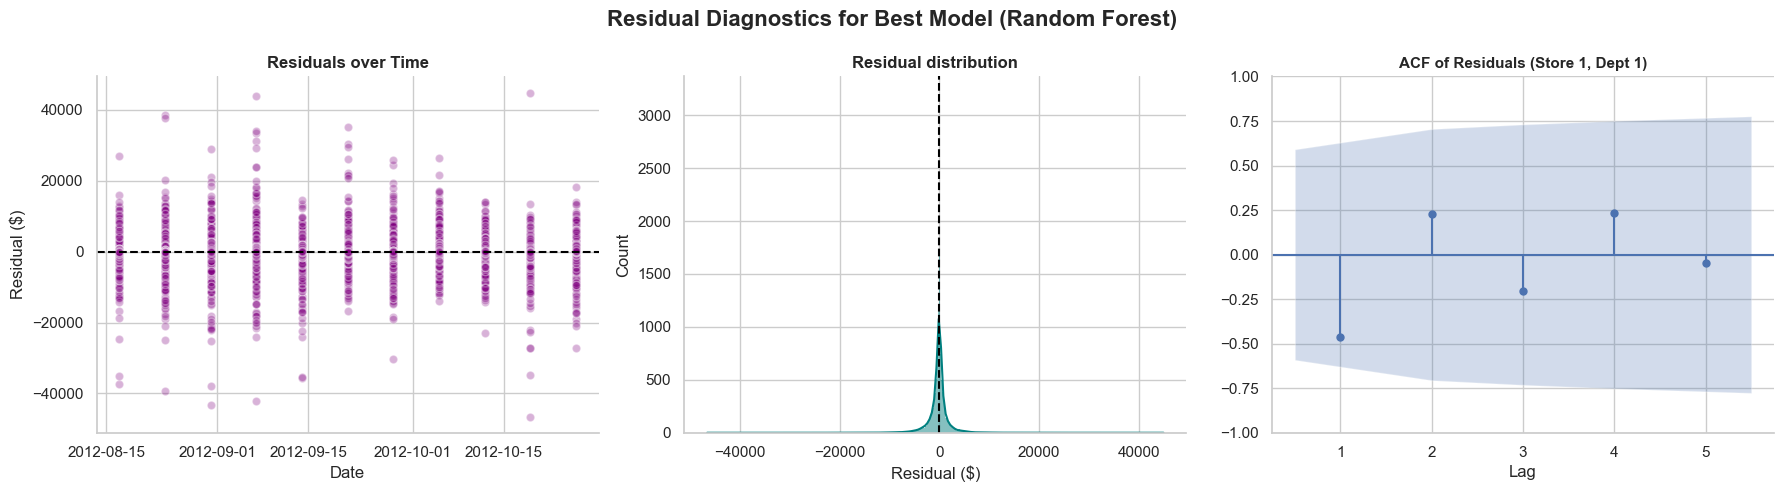

In [11]:
best_model_name = metrics_df.iloc[0]["Model"]
best_col = f"{best_model_name}_Pred"
residuals = val_df["Weekly_Sales"] - val_df[best_col]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals over time
axes[0].scatter(val_df["Date"], residuals, alpha=0.3, color="purple", edgecolors="w")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuals over Time", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual ($)")

# 2. Residuals distribution
sns.histplot(residuals, kde=True, ax=axes[1], color="teal")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Residual ($)")

# 3. Residual ACF for the highest-volume group in the dataset
unique_groups = val_df[["Store", "Dept"]].drop_duplicates().values
top_group = unique_groups[0]
top_group_val = val_df[(val_df["Store"] == top_group[0]) & (val_df["Dept"] == top_group[1])].sort_values("Date")
group_residuals = top_group_val["Weekly_Sales"] - top_group_val[best_col]

if len(group_residuals) >= 6:
    max_lags = min(5, len(group_residuals) // 2)
    plot_acf(group_residuals, ax=axes[2], lags=max_lags, zero=False)
    axes[2].set_title(f"ACF of Residuals (Store {top_group[0]}, Dept {top_group[1]})", fontsize=11, fontweight="bold")
else:
    axes[2].text(0.5, 0.5, 'Insufficient residual observations', ha='center', va='center')
    axes[2].set_title(f'ACF of Residuals (Store {top_group[0]}, Dept {top_group[1]})', fontsize=11, fontweight='bold')
axes[2].set_xlabel("Lag")

plt.suptitle(f'Residual Diagnostics for Best Model ({best_model_name})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Forecast Error Across Validation Period

We trace the MAE of each model week-by-week over the 12-week validation timeline.

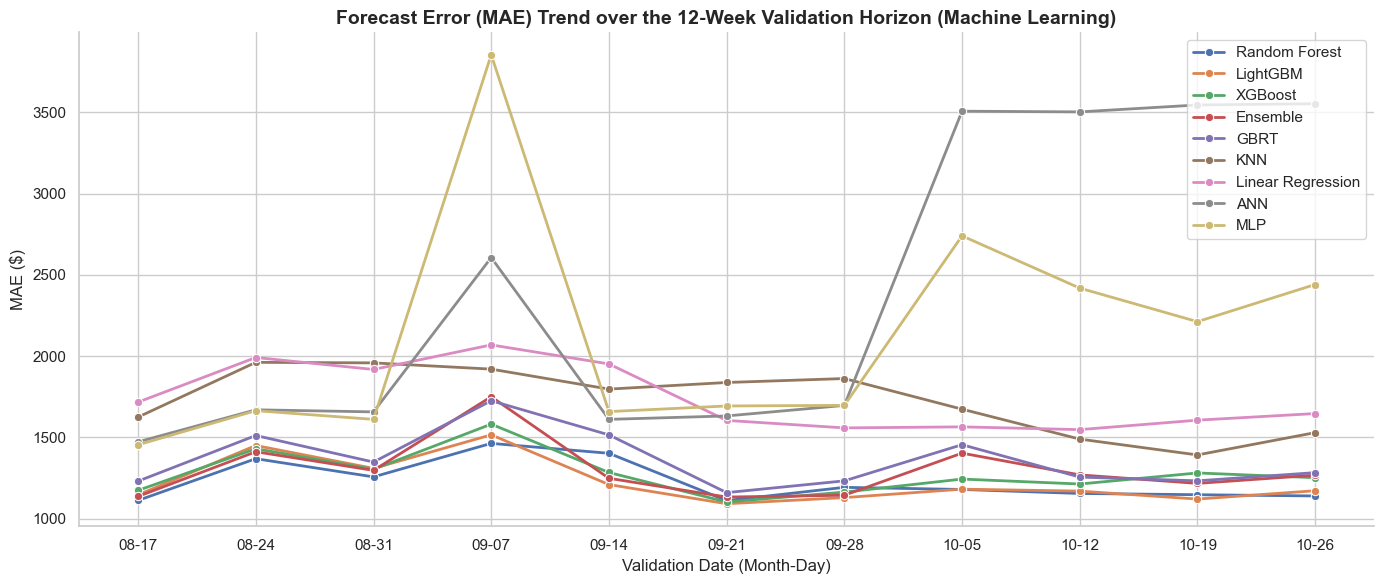

In [12]:
week_errors = []
dates = sorted(val_df["Date"].unique())

for date in dates:
    subset = val_df[val_df["Date"] == date]
    for name in model_names:
        col_name = f"{name}_Pred"
        mae_val = calculate_mae(subset["Weekly_Sales"], subset[col_name])
        week_errors.append({
            "Date": date.strftime("%m-%d"),
            "Model": name,
            "MAE": mae_val
        })

week_err_df = pd.DataFrame(week_errors)

plt.figure(figsize=(14, 6))
sns.lineplot(data=week_err_df, x="Date", y="MAE", hue="Model", marker="o", linewidth=2.0)
plt.title('Forecast Error (MAE) Trend over the 12-Week Validation Horizon (Machine Learning)', fontsize=14, fontweight='bold')
plt.xlabel("Validation Date (Month-Day)", fontsize=12)
plt.ylabel("MAE ($)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 13. Model Win Count

For a sample of 500 Store-Department groups, we check which model gets the lowest validation WMAE.

C:\Users\rahul\AppData\Local\Temp\ipykernel_24316\2517331285.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.index, y=win_counts.values, palette="viridis")


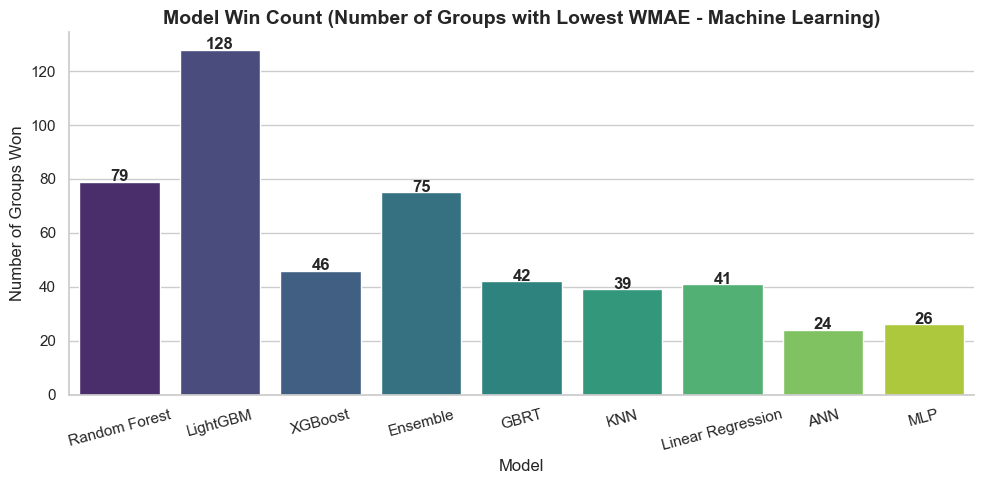

In [13]:
unique_groups = val_df[["Store", "Dept"]].drop_duplicates().values
group_wins = []

for store, dept in unique_groups[:500]:
    grp_val = val_df[(val_df["Store"] == store) & (val_df["Dept"] == dept)]
    best_group_wmae = float("inf")
    winning_model = None
    
    for name in model_names:
        col_name = f"{name}_Pred"
        wmae_val = calculate_wmae(grp_val["Weekly_Sales"], grp_val[col_name], grp_val["IsHoliday"])
        if wmae_val < best_group_wmae:
            best_group_wmae = wmae_val
            winning_model = name
            
    group_wins.append(winning_model)

win_counts = pd.Series(group_wins).value_counts().reindex(model_names).fillna(0).astype(int)

plt.figure(figsize=(10, 5))
sns.barplot(x=win_counts.index, y=win_counts.values, palette="viridis")
plt.title('Model Win Count (Number of Groups with Lowest WMAE - Machine Learning)', fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Number of Groups Won", fontsize=12)
plt.xticks(rotation=15)

for idx, val in enumerate(win_counts.values):
    plt.text(idx, val + 0.2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Save Predictions and Metrics

In [14]:
if Path("results").exists():
    output_dir = Path("results")
else:
    output_dir = Path("../results")
output_dir.mkdir(parents=True, exist_ok=True)

# Save predictions
pred_path = output_dir / "ml_predictions.csv"
val_df.to_csv(pred_path, index=False)
print(f"Predictions saved successfully to: {pred_path.resolve()}")

# Save metrics
metrics_path = output_dir / "ml_metrics.json"
metrics_dict_save = metrics_df.set_index("Model").to_dict(orient="index")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict_save, f, indent=4)
print(f"Metrics saved successfully to: {metrics_path.resolve()}")

Predictions saved successfully to: D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization\results\ml_predictions.csv
Metrics saved successfully to: D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization\results\ml_metrics.json


## 15. Key Findings & Conclusions

In [15]:
best_row = metrics_df.iloc[0]
print("=== SUMMARY OF KEY FINDINGS ===")
print(f"Best Performing Machine Learning Model: {best_row['Model']}")
print(f"Validation WMAE:                        {best_row['WMAE']:,.2f}")

=== SUMMARY OF KEY FINDINGS ===
Best Performing Machine Learning Model: Random Forest
Validation WMAE:                        1,292.53
